In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')


In [3]:
datasets = {
    'orders': orders, 'customers': customers,
    'order_items': order_items, 'payments': payments,
    'products': products, 'sellers': sellers,
    'reviews': reviews, 'translation': translation
}

for name, df in datasets.items():
    print(f"{name:15} → {df.shape[0]:>6} rows, {df.shape[1]:>2} cols")

orders          →  99441 rows,  8 cols
customers       →  99441 rows,  5 cols
order_items     → 112650 rows,  7 cols
payments        → 103886 rows,  5 cols
products        →  32951 rows,  9 cols
sellers         →   3095 rows,  4 cols
reviews         →  99224 rows,  7 cols
translation     →     71 rows,  2 cols


In [4]:
print('ORDERS')
print(orders.dtypes)
print('\n missing values')
print (orders.isnull().sum())

ORDERS
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

 missing values
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


## Convert the Date Columns

In [7]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])
print(orders.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


## Investigate the Missing Values

In [9]:
missing_delivery = orders[orders['order_delivered_customer_date'].isnull()]
print("Order status for missing delivery dates:")
print(missing_delivery['order_status'].value_counts())

Order status for missing delivery dates:
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64


In [11]:
orders_customers = pd.merge(orders, customers, on='customer_id', how='inner')
print(f"Merged dataset shape: {orders_customers.shape}")
print("\nFirst 3 rows:")
display(orders_customers.head(3))

Merged dataset shape: (99441, 12)

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


## Where are the customers? (Geographical EDA)

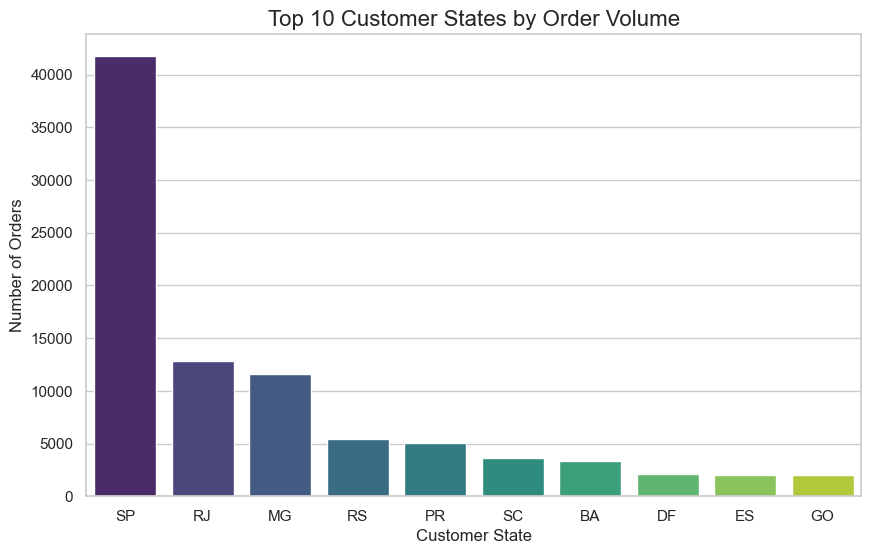

In [12]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

top_states = orders_customers['customer_state'].value_counts().head(10)

# Create a bar plot
sns.barplot(x=top_states.index, y=top_states.values, palette="viridis")

plt.title('Top 10 Customer States by Order Volume', fontsize=16)
plt.xlabel('Customer State', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.show()

## Bringing in the Revenue Data

In [14]:
master_df = pd.merge(orders_customers, order_items, on='order_id', how='inner')

print(f"New Master Dataset Shape: {master_df.shape}")
print(f"Total Revenue in Dataset: ${master_df['price'].sum():,.2f}")

# Preview the financial columns
display(master_df[['order_id', 'price', 'freight_value']].head())

New Master Dataset Shape: (112650, 18)
Total Revenue in Dataset: $13,591,643.70


,order_id,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,19.90,8.72


## Building the Cohort Analysis

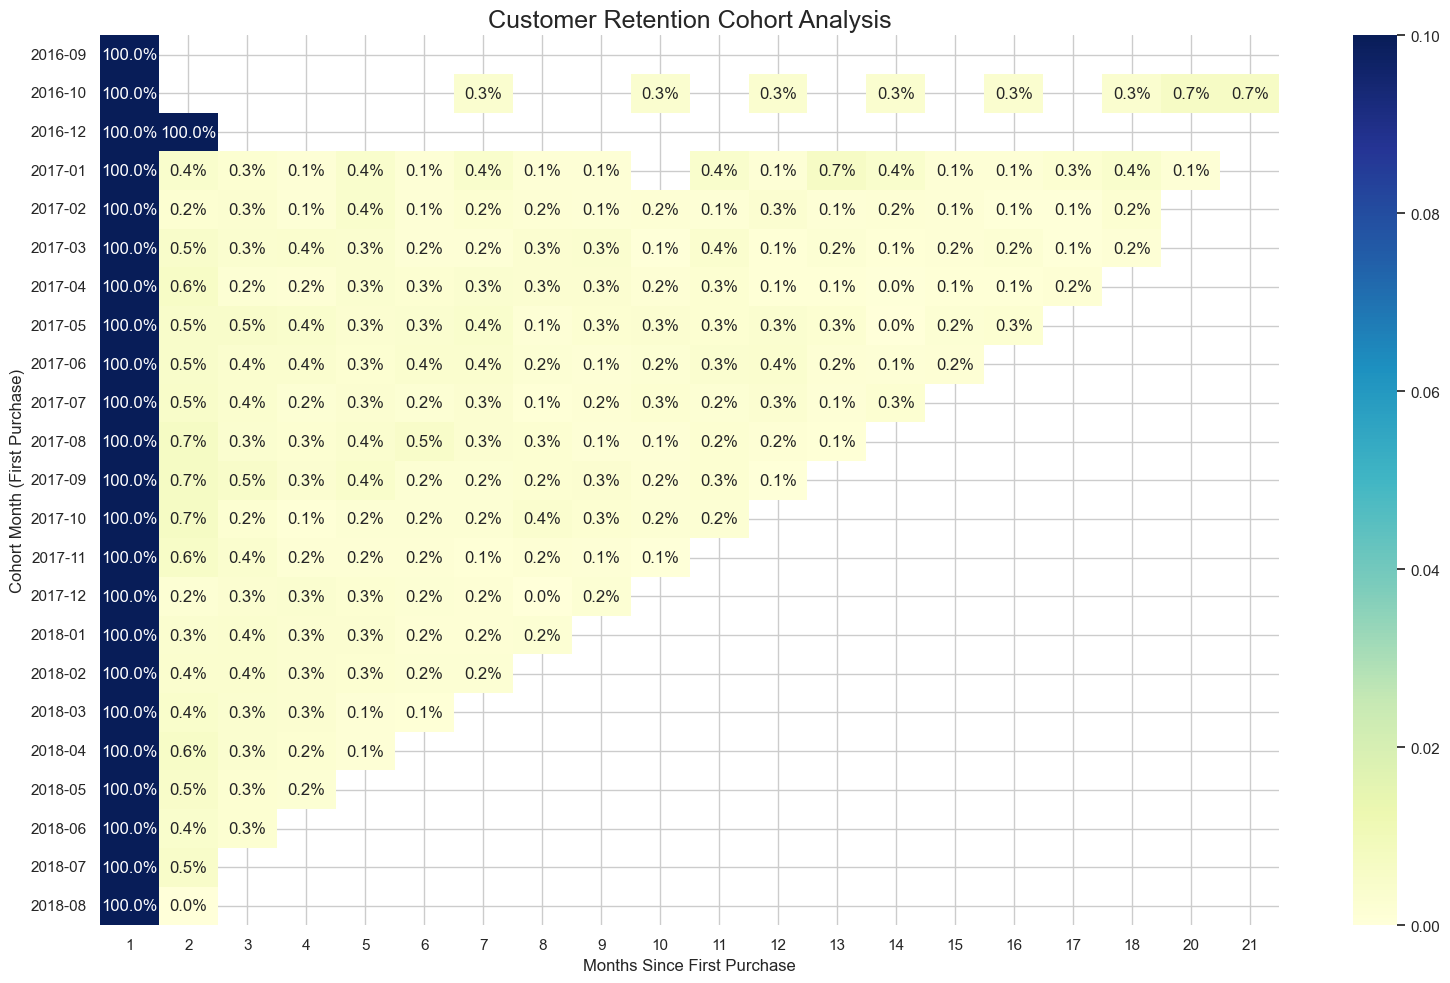

In [17]:
# 1. Create a 'purchase_month' column
master_df['purchase_month'] = master_df['order_purchase_timestamp'].dt.to_period('M')

# 2. Find cohort_month using customer_unique_id (not customer_id — each order gets a new customer_id in Olist)
master_df['cohort_month'] = master_df.groupby('customer_unique_id')['purchase_month'].transform('min')

# 3. Count unique REAL customers per cohort per month
cohort_data = master_df.groupby(['cohort_month', 'purchase_month'])['customer_unique_id'].nunique().reset_index()

# 4. Calculate cohort index
def calculate_cohort_index(df):
    cohort_year = df['cohort_month'].dt.year
    cohort_month_num = df['cohort_month'].dt.month
    purchase_year = df['purchase_month'].dt.year
    purchase_month_num = df['purchase_month'].dt.month
    years_diff = purchase_year - cohort_year
    months_diff = purchase_month_num - cohort_month_num
    return years_diff * 12 + months_diff + 1

cohort_data['cohort_index'] = calculate_cohort_index(cohort_data)

# 5. Pivot into matrix
cohort_counts = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_unique_id')

# 6. Convert to retention percentages
cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0)
retention.index = retention.index.astype(str)

# 7. Visualize
plt.figure(figsize=(16, 10))
plt.title('Customer Retention Cohort Analysis', fontsize=18)
sns.heatmap(retention, annot=True, fmt='.1%', cmap='YlGnBu', vmin=0.0, vmax=0.1)
plt.ylabel('Cohort Month (First Purchase)', fontsize=12)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
# Export your cleaned master dataset to a new CSV file
# We use index=False so pandas doesn't write the row numbers into the file
master_df.to_csv('olist_cleaned_master.csv', index=False)

print("Export Complete! You can now load this file into Power BI.")

Export Complete! You can now load this file into Power BI.


In [21]:
import os
print(os.path.exists('olist_cleaned_master.csv'))
print(f"File size: {os.path.getsize('olist_cleaned_master.csv') / 1024 / 1024:.1f} MB")

True
File size: 36.1 MB
